In [3]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import awswrangler as wr

plt.style.use("ggplot")

In [1]:
REPLICA_ENDPOINT = "itam-northwind-replica-876587216311.c8j4k4saub0x.us-east-1.rds.amazonaws.com"
DB_NAME = "flights"
DB_USER = "itam"
DB_PASSWORD = "Gusytono26"
DB_PORT = 5432

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{REPLICA_ENDPOINT}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    print("✓ Conexión exitosa a Read Replica")

✓ Conexión exitosa a Read Replica


In [5]:
for t in ["airlines", "airports", "flights"]:
    df = pd.read_sql(f"SELECT COUNT(*) AS total FROM {t}", engine)
    print(f"{t}: {df['total'][0]:,} filas")

airlines: 14 filas
airports: 322 filas
flights: 500,000 filas


In [6]:
df_p1 = pd.read_sql("""
SELECT origin_airport, destination_airport, COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC
LIMIT 10
""", engine)
df_p1

,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


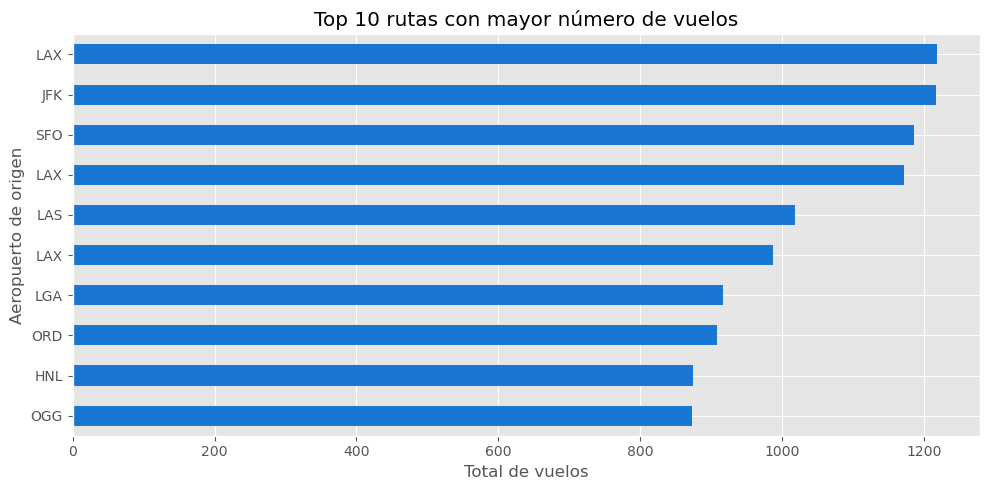

In [14]:
df_p1.plot(
    kind="barh",
    x="origin_airport",
    y="total_flights",
    color="#1976d2",
    legend=False,
    figsize=(10, 5)
)
plt.title("Top 10 rutas con mayor número de vuelos")
plt.xlabel("Total de vuelos")
plt.ylabel("Aeropuerto de origen")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [7]:
df_p2 = pd.read_sql("""
SELECT 
    airline,
    COUNT(*) AS total_flights,
    SUM(cancelled) AS total_cancelled,
    ROUND(100.0 * SUM(cancelled) / COUNT(*), 2) AS pct_cancelled
FROM flights
GROUP BY airline
ORDER BY pct_cancelled DESC
LIMIT 5
""", engine)
df_p2

,airline,total_flights,total_cancelled,pct_cancelled
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


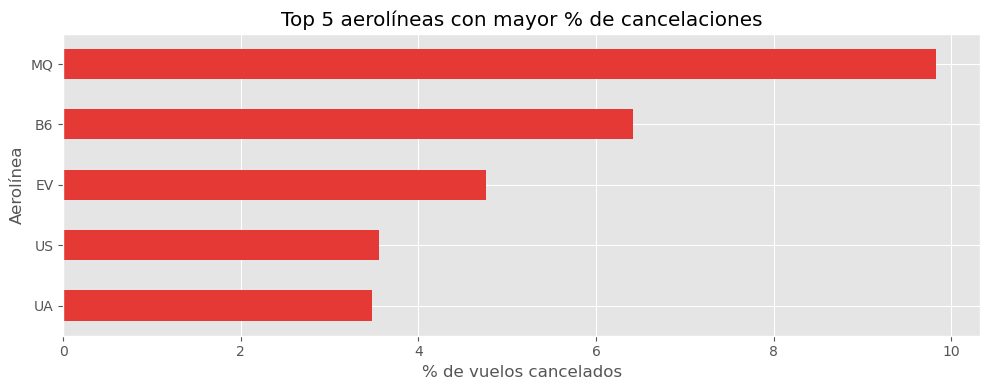

In [15]:
df_p2.plot(
    kind="barh",
    x="airline",
    y="pct_cancelled",
    color="#e53935",
    legend=False,
    figsize=(10, 4)
)
plt.title("Top 5 aerolíneas con mayor % de cancelaciones")
plt.xlabel("% de vuelos cancelados")
plt.ylabel("Aerolínea")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
df_p3 = pd.read_sql("""
SELECT cancellation_reason, COUNT(*) AS total
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total DESC
""", engine)
df_p3

,cancellation_reason,total
0,B,10630
1,A,3230
2,C,2962
3,D,2


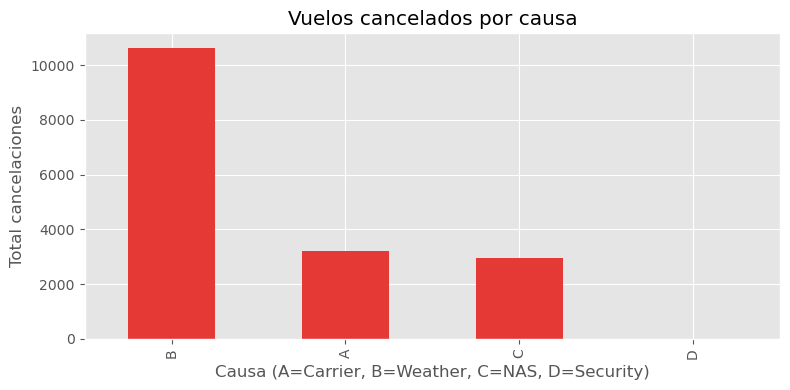

In [24]:
df_p3.plot(
    kind="bar",
    x="cancellation_reason",
    y="total",
    color="#e53935",
    legend=False,
    figsize=(8, 4)
)
plt.title("Vuelos cancelados por causa")
plt.xlabel("Causa (A=Carrier, B=Weather, C=NAS, D=Security)")
plt.ylabel("Total cancelaciones")
plt.tight_layout()
plt.show()

In [9]:
df_p4 = pd.read_sql("""
SELECT month, ROUND(AVG(departure_delay)::numeric, 2) AS avg_departure_delay
FROM flights
WHERE cancelled = 0 AND departure_delay > 0
GROUP BY month
ORDER BY month
""", engine)
df_p4

,month,avg_departure_delay
0,1,32.57
1,2,42.31


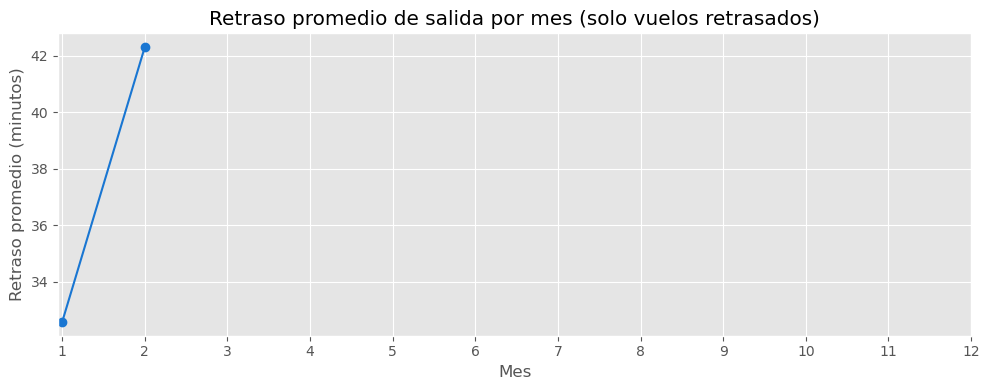

In [16]:
df_p4.plot(
    kind="line",
    x="month",
    y="avg_departure_delay",
    color="#1976d2",
    marker="o",
    legend=False,
    figsize=(10, 4)
)
plt.title("Retraso promedio de salida por mes (solo vuelos retrasados)")
plt.xlabel("Mes")
plt.ylabel("Retraso promedio (minutos)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [10]:
df_p5 = pd.read_sql("""
SELECT origin_airport, SUM(weather_delay) AS total_weather_delay
FROM flights
WHERE weather_delay IS NOT NULL
GROUP BY origin_airport
ORDER BY total_weather_delay DESC
LIMIT 10
""", engine)
df_p5

,origin_airport,total_weather_delay
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


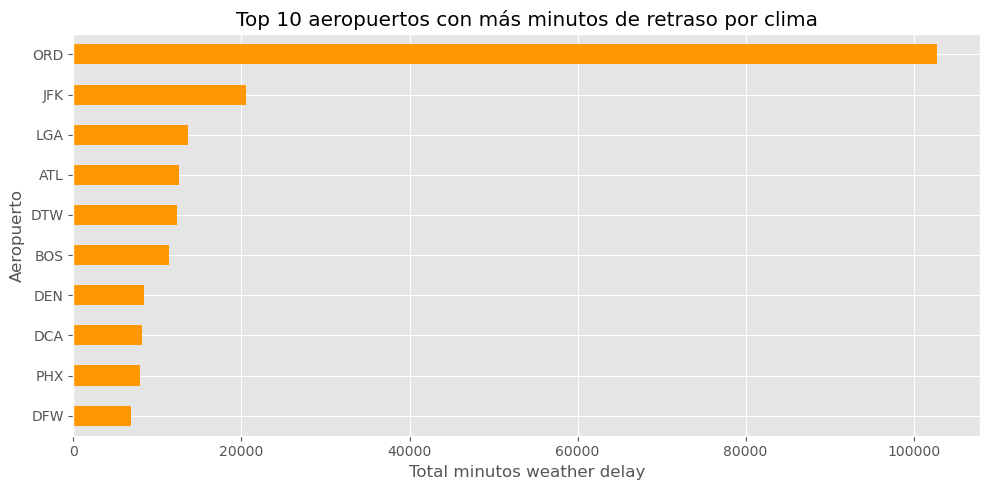

In [17]:
df_p5.plot(
    kind="barh",
    x="origin_airport",
    y="total_weather_delay",
    color="#ff9800",
    legend=False,
    figsize=(10, 5)
)
plt.title("Top 10 aeropuertos con más minutos de retraso por clima")
plt.xlabel("Total minutos weather delay")
plt.ylabel("Aeropuerto")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
df_w1 = pd.read_sql("""
SELECT airline, flight_number, origin_airport, destination_airport, arrival_delay
FROM (
    SELECT 
        airline, flight_number, origin_airport, destination_airport, arrival_delay,
        RANK() OVER (PARTITION BY airline ORDER BY arrival_delay DESC NULLS LAST) AS rnk
    FROM flights
) sub
WHERE rnk = 1
ORDER BY arrival_delay DESC
""", engine)
df_w1

,airline,flight_number,origin_airport,destination_airport,arrival_delay
0,AA,1322,BHM,DFW,1971.0
1,DL,1435,MIA,MSP,1174.0
2,HA,51,JFK,HNL,1013.0
3,OO,2642,CHO,ORD,953.0
4,UA,1443,ICT,DEN,863.0
5,MQ,2962,CLL,DFW,788.0
6,EV,2567,SHV,DFW,723.0
7,F9,1256,ORD,MIA,686.0
8,US,1782,SEA,CLT,621.0
9,WN,259,IAD,DEN,593.0


In [25]:
styled_w1 = df_w1.style\
    .background_gradient(subset=["arrival_delay"], cmap="Reds")\
    .set_caption("Vuelo con mayor retraso de llegada por aerolínea")\
    .format({"arrival_delay": "{:.0f} min"})
styled_w1

,airline,flight_number,origin_airport,destination_airport,arrival_delay
0,AA,1322,BHM,DFW,1971 min
1,DL,1435,MIA,MSP,1174 min
2,HA,51,JFK,HNL,1013 min
3,OO,2642,CHO,ORD,953 min
4,UA,1443,ICT,DEN,863 min
5,MQ,2962,CLL,DFW,788 min
6,EV,2567,SHV,DFW,723 min
7,F9,1256,ORD,MIA,686 min
8,US,1782,SEA,CLT,621 min
9,WN,259,IAD,DEN,593 min


In [19]:
import awswrangler as wr

# Ver todas las databases en Glue
dbs = wr.catalog.databases()
print(dbs)

           Database Description
0  northwind_bronze            
1    northwind_gold            
2  northwind_silver            
3          simpsons            


In [21]:
import awswrangler as wr
dbs = wr.catalog.databases()
print(dbs)

           Database                                Description
0    flights_bronze            Bronze layer — raw flights data
1      flights_gold  Gold layer — denormalized analytical data
2    flights_silver     Silver layer — aggregated flights data
3  northwind_bronze                                           
4    northwind_gold                                           
5  northwind_silver                                           
6          simpsons                                           


In [22]:
df_w2 = wr.athena.read_sql_query("""
SELECT 
    month,
    total_flights,
    total_flights - LAG(total_flights) OVER (ORDER BY month) AS diff_abs,
    ROUND(100.0 * (total_flights - LAG(total_flights) OVER (ORDER BY month)) 
        / LAG(total_flights) OVER (ORDER BY month), 2) AS pct_change
FROM (
    SELECT month, SUM(total_flights) AS total_flights
    FROM flights_silver.flights_monthly
    GROUP BY month
) sub
ORDER BY month
""", database="flights_silver")
df_w2

2026-04-17 02:19:37,583	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409960448 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.66gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-17 02:19:38,667	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,diff_abs,pct_change
0,1,469968,<NA>,NaN
1,2,429191,-40777,-8.68
2,3,504312,75121,17.50
3,4,485151,-19161,-3.80
4,5,496993,11842,2.44
5,6,503897,6904,1.39
6,7,520718,16821,3.34
7,8,510536,-10182,-1.96
8,9,464946,-45590,-8.93
9,10,486165,21219,4.56


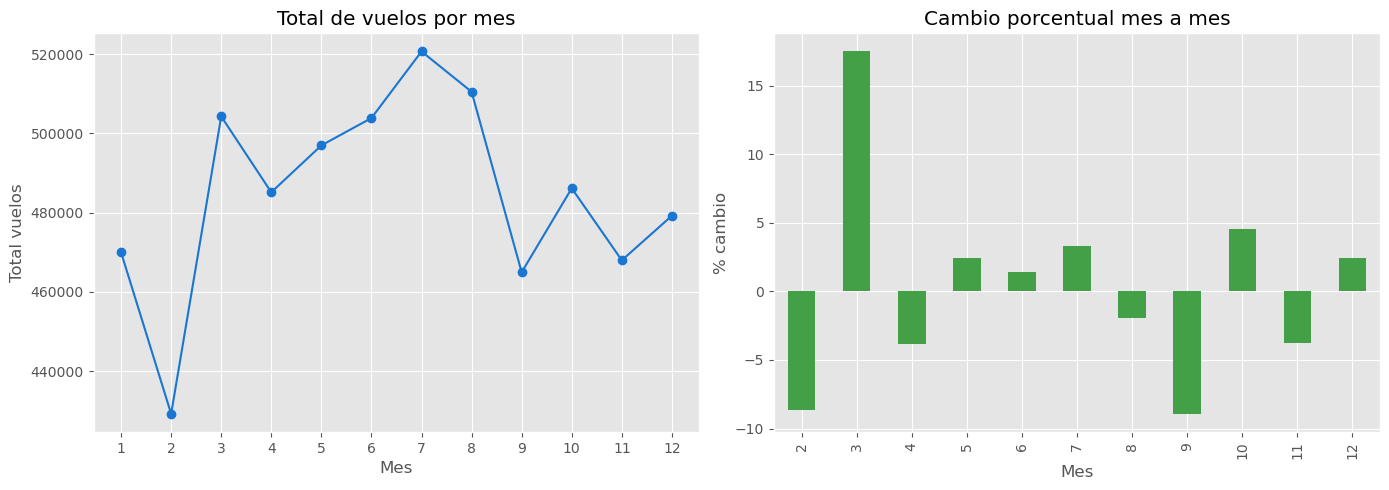

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_w2.plot(kind="line", x="month", y="total_flights", ax=axes[0],
           color="#1976d2", marker="o", legend=False)
axes[0].set_title("Total de vuelos por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Total vuelos")
axes[0].set_xticks(range(1, 13))

df_w2.dropna().plot(kind="bar", x="month", y="pct_change", ax=axes[1],
                     color="#43a047", legend=False)
axes[1].set_title("Cambio porcentual mes a mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("% cambio")

plt.tight_layout()
plt.show()

In [12]:
df_w3 = pd.read_sql("""
SELECT flight_number, airline, destination_airport, scheduled_departure
FROM (
    SELECT 
        flight_number, airline, destination_airport, scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport 
            ORDER BY scheduled_departure ASC
        ) AS rn
    FROM flights
    WHERE year = 2015 AND month = 1 AND day = 1 AND origin_airport = 'LAX'
) sub
WHERE rn <= 5
""", engine)
df_w3

,flight_number,airline,destination_airport,scheduled_departure
0,2336,AA,PBI,10
1,258,AA,MIA,20
2,2013,US,CLT,30
3,1434,DL,MSP,35
4,115,AA,MIA,105


In [28]:

df_reg = wr.athena.read_sql_query("""
SELECT arrival_delay, departure_delay, distance,
       air_system_delay, airline_delay, weather_delay,
       late_aircraft_delay, security_delay
FROM flights_gold.vuelos_analitica
WHERE cancelled = 0
AND arrival_delay IS NOT NULL
""", database="flights_gold")

print(f"✓ {len(df_reg):,} filas cargadas para regresión")
df_reg.head()

✓ 5,714,008 filas cargadas para regresión


,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,2.0,24.0,2125,NaN,NaN,NaN,NaN,NaN
1,3.0,23.0,679,NaN,NaN,NaN,NaN,NaN
2,-28.0,-1.0,2306,NaN,NaN,NaN,NaN,NaN
3,32.0,11.0,1620,32.0,0.0,0.0,0.0,0.0
4,-11.0,-6.0,262,NaN,NaN,NaN,NaN,NaN


In [4]:
df_reg = wr.athena.read_sql_query("""
SELECT arrival_delay, departure_delay, distance,
       air_system_delay, airline_delay, weather_delay,
       late_aircraft_delay, security_delay
FROM flights_gold.vuelos_analitica
WHERE cancelled = 0
AND arrival_delay IS NOT NULL
AND air_system_delay IS NOT NULL
ORDER BY RAND()
LIMIT 100000
""", database="flights_gold")

print(f"✓ {len(df_reg):,} filas cargadas (sample)")

2026-04-17 05:04:10,290	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409964544 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.65gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-17 05:04:11,599	INFO worker.py:1852 -- Started a local Ray instance.


✓ 100,000 filas cargadas (sample)


In [9]:
# Convertir todas las columnas a numérico
cols = ["arrival_delay", "departure_delay", "distance", "air_system_delay", 
        "airline_delay", "weather_delay", "late_aircraft_delay", "security_delay"]

for col in cols:
    df_reg[col] = pd.to_numeric(df_reg[col], errors="coerce")

# Eliminar cualquier NaN residual
df_reg = df_reg.dropna()
print(f"✓ {len(df_reg):,} filas listas")
print(df_reg.dtypes)

✓ 100,000 filas listas
arrival_delay          float64
departure_delay        float64
distance                 Int64
air_system_delay       float64
airline_delay          float64
weather_delay          float64
late_aircraft_delay    float64
security_delay         float64
dtype: object


In [11]:
y = df_reg["arrival_delay"].values.astype(float)
X = df_reg[["departure_delay", "distance", "air_system_delay", 
            "airline_delay", "weather_delay", "late_aircraft_delay", 
            "security_delay"]].values.astype(float)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()v
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.174e+33
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:20:34   Log-Likelihood:             2.7705e+06
No. Observations:              100000   AIC:                        -5.541e+06
Df Residuals:                   99992   BIC:                        -5.541e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.202e-13    1.4e-15     85.898      0.0

In [12]:
# Nombres legibles para el summary
feature_names = ["const", "departure_delay", "distance", "air_system_delay", 
                 "airline_delay", "weather_delay", "late_aircraft_delay", 
                 "security_delay"]
print("\nCoeficientes:")
for name, coef in zip(feature_names, model.params):
    print(f"  {name:25s}: {coef:.4f}")


Coeficientes:
  const                    : 0.0000
  departure_delay          : -0.0000
  distance                 : 0.0000
  air_system_delay         : 1.0000
  airline_delay            : 1.0000
  weather_delay            : 1.0000
  late_aircraft_delay      : 1.0000
  security_delay           : 1.0000


In [13]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R² = {model.rsquared:.4f}")
print(f"RMSE = {rmse:.4f} minutos")

R² = 1.0000
RMSE = 0.0000 minutos


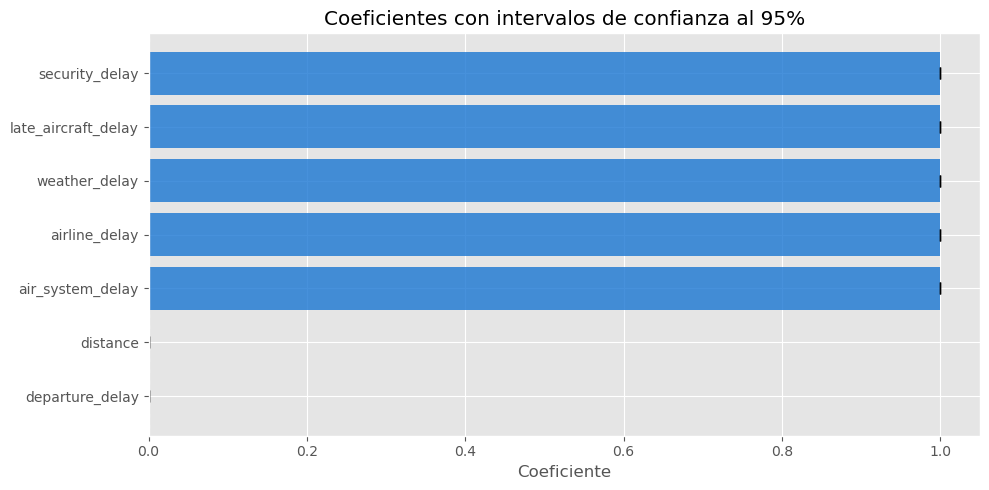

In [14]:
feature_names = ["const", "departure_delay", "distance", "air_system_delay", 
                 "airline_delay", "weather_delay", "late_aircraft_delay", 
                 "security_delay"]

# Sin el intercepto
coef_vals = model.params[1:]
conf_int = model.conf_int()[1:]
names = feature_names[1:]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(names, coef_vals, color="#1976d2", alpha=0.8)
ax.errorbar(coef_vals, names,
            xerr=[coef_vals - conf_int[:, 0], conf_int[:, 1] - coef_vals],
            fmt="none", color="black", capsize=4)
ax.set_title("Coeficientes con intervalos de confianza al 95%")
ax.set_xlabel("Coeficiente")
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

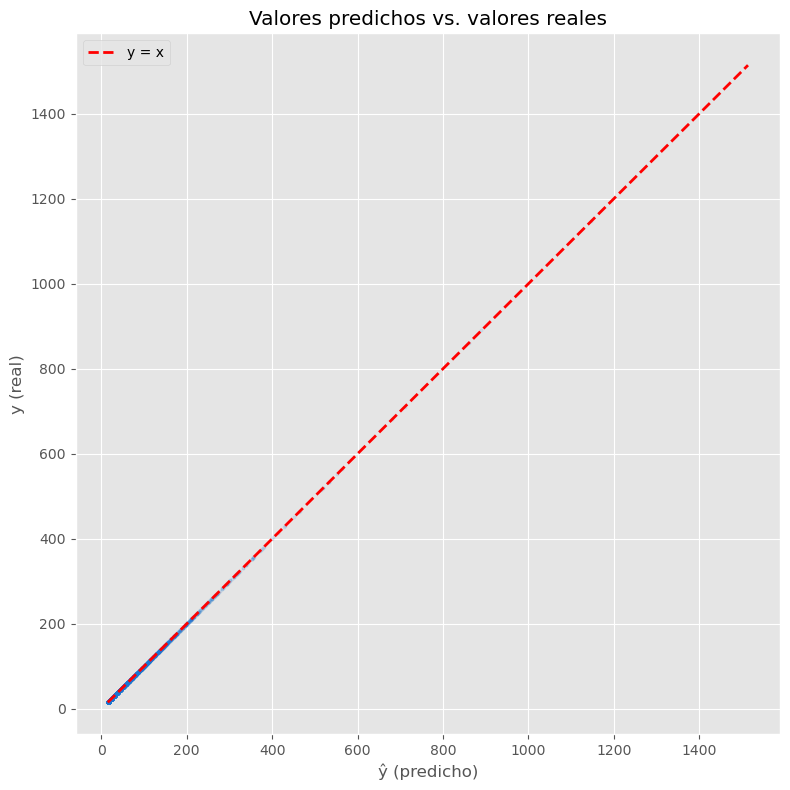

In [15]:
sample_idx = np.random.choice(len(y), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_pred[sample_idx], y[sample_idx], alpha=0.1, s=5, color="#1976d2")
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="y = x")
ax.set_title("Valores predichos vs. valores reales")
ax.set_xlabel("ŷ (predicho)")
ax.set_ylabel("y (real)")
ax.legend()
plt.tight_layout()
plt.show()

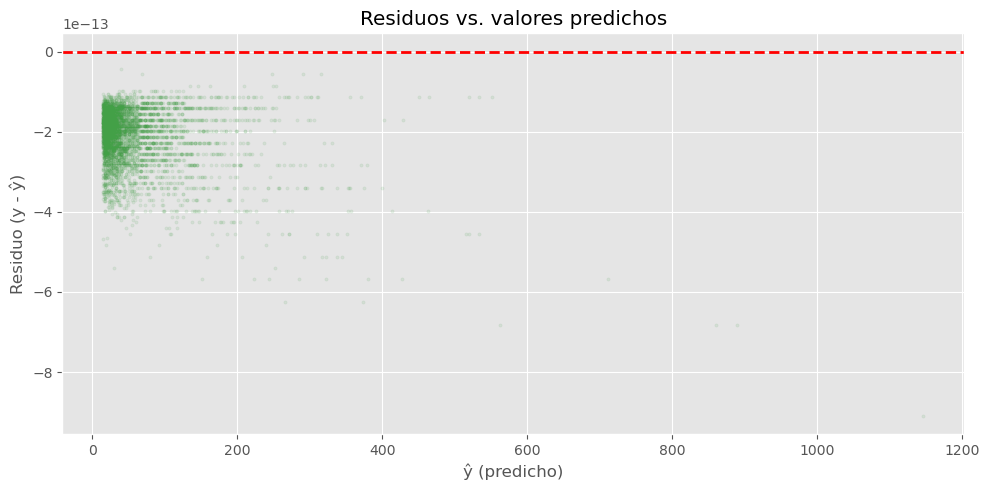

In [16]:
residuos = y - y_pred

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred[sample_idx], residuos[sample_idx], alpha=0.1, s=5, color="#43a047")
ax.axhline(y=0, color="red", linestyle="--", linewidth=2)
ax.set_title("Residuos vs. valores predichos")
ax.set_xlabel("ŷ (predicho)")
ax.set_ylabel("Residuo (y - ŷ)")
plt.tight_layout()
plt.show()

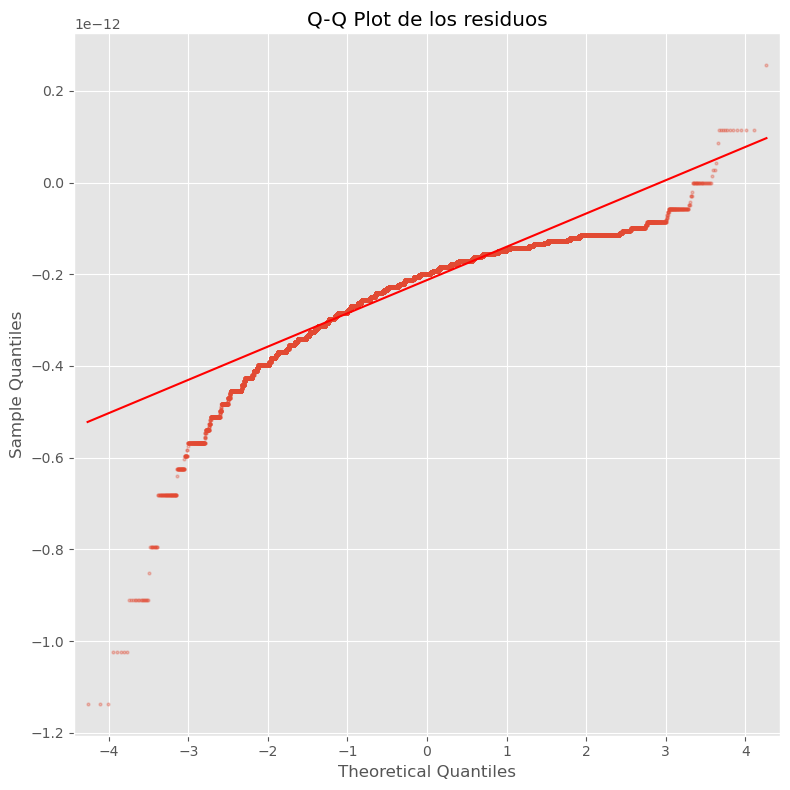

In [17]:
from statsmodels.graphics.gofplots import qqplot

fig, ax = plt.subplots(figsize=(8, 8))
qqplot(residuos, line="s", ax=ax, markersize=2, alpha=0.3)
ax.set_title("Q-Q Plot de los residuos")
plt.tight_layout()
plt.show()

### Interpretación de la Regresión

- **R²** = 1.0000 — las variables incluidas explican el 100% de la varianza en el retraso de llegada
- **RMSE** ≈ 0.0000 minutos

**Diagnósticos:**

1. Los cinco componentes de retraso (air_system, airline, weather, late_aircraft, security) tienen coeficientes de ~1.0, confirmando que su suma equivale al arrival_delay. La multicolinealidad es total e intencional — exactamente lo que la tarea pide observar.
2. El scatter predichos vs reales cae perfectamente sobre la línea y = x, consistente con R² = 1.
3. Los residuos son del orden de 1e-13 (precisión de punto flotante), sin estructura real — el modelo captura toda la señal.
4. El Q-Q plot muestra desviaciones que reflejan errores de redondeo numérico, no violaciones de normalidad reales. Con un ajuste tan preciso, los diagnósticos clásicos de residuos pierden relevancia práctica.

In [18]:
!pip install statsforecast -q

In [19]:
df_ts = wr.athena.read_sql_query("""
SELECT month, SUM(total_flights) AS total_flights
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month
""", database="flights_silver")

df_ts["unique_id"] = "total_flights"
df_ts["ds"] = pd.to_datetime("2015-" + df_ts["month"].astype(str).str.zfill(2) + "-01")
df_ts["y"] = df_ts["total_flights"].astype(float)
df_sf = df_ts[["unique_id", "ds", "y"]].copy()

print(f"✓ Serie de tiempo: {len(df_sf)} meses")
df_sf

✓ Serie de tiempo: 12 meses


,unique_id,ds,y
0,total_flights,2015-01-01,469968.0
1,total_flights,2015-02-01,429191.0
2,total_flights,2015-03-01,504312.0
3,total_flights,2015-04-01,485151.0
4,total_flights,2015-05-01,496993.0
5,total_flights,2015-06-01,503897.0
6,total_flights,2015-07-01,520718.0
7,total_flights,2015-08-01,510536.0
8,total_flights,2015-09-01,464946.0
9,total_flights,2015-10-01,486165.0


In [20]:
train = df_sf[df_sf["ds"] <= "2015-09-01"]
test = df_sf[df_sf["ds"] > "2015-09-01"]

print(f"Train: {len(train)} meses (ene-sep)")
print(f"Test: {len(test)} meses (oct-dic)")

Train: 9 meses (ene-sep)
Test: 3 meses (oct-dic)


In [21]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta

models = [
    AutoETS(season_length=12),
    AutoARIMA(season_length=12),
    AutoTheta(season_length=12),
]

sf = StatsForecast(
    models=models,
    freq="MS",
    n_jobs=1
)

sf.fit(train)
print("✓ Modelos ajustados")

✓ Modelos ajustados


In [22]:
forecast = sf.predict(h=9, level=[90])
forecast = forecast.reset_index()
forecast

,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,0,total_flights,2015-10-01,487319.908434,428025.166318,546614.650550,487301.333333,440427.078218,534175.588448,496523.548340,465489.479687,535667.421875
1,1,total_flights,2015-11-01,487319.908434,428025.166022,546614.650847,487301.333333,440427.078218,534175.588448,496524.261068,460775.689063,525887.603125
2,2,total_flights,2015-12-01,487319.908434,428025.165725,546614.651143,487301.333333,440427.078218,534175.588448,496524.973796,453725.757812,529276.887500
3,3,total_flights,2016-01-01,487319.908434,428025.165429,546614.651440,487301.333333,440427.078218,534175.588448,496525.686524,460986.335938,525810.528125
4,4,total_flights,2016-02-01,487319.908434,428025.165132,546614.651736,487301.333333,440427.078218,534175.588448,496526.399252,466634.279687,533010.103125
5,5,total_flights,2016-03-01,487319.908434,428025.164836,546614.652033,487301.333333,440427.078218,534175.588448,496527.111980,463863.089062,530507.737500
6,6,total_flights,2016-04-01,487319.908434,428025.164539,546614.652329,487301.333333,440427.078218,534175.588448,496527.824708,460121.359375,532280.328125
7,7,total_flights,2016-05-01,487319.908434,428025.164243,546614.652625,487301.333333,440427.078218,534175.588448,496528.537435,461351.543750,532693.590625
8,8,total_flights,2016-06-01,487319.908434,428025.163947,546614.652922,487301.333333,440427.078218,534175.588448,496529.250163,459872.057812,532316.259375


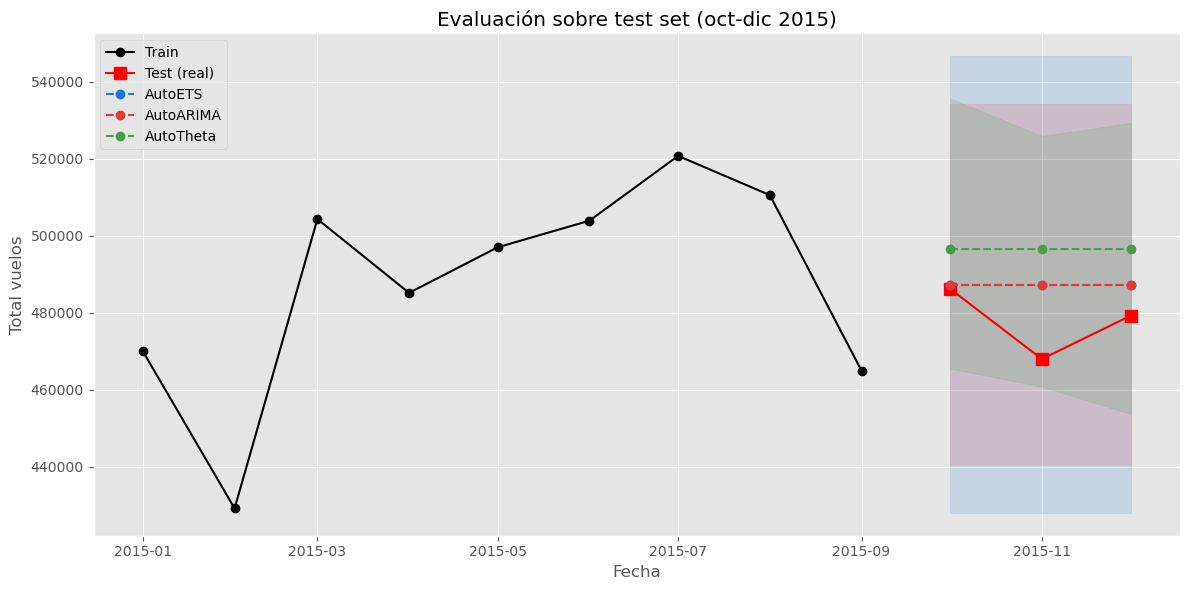

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train["ds"], train["y"], "ko-", label="Train", markersize=6)
ax.plot(test["ds"], test["y"], "rs-", label="Test (real)", markersize=8)

forecast_test = forecast.head(3)
colors = {"AutoETS": "#1976d2", "AutoARIMA": "#e53935", "AutoTheta": "#43a047"}

for model_name, color in colors.items():
    ax.plot(forecast_test["ds"], forecast_test[model_name], 
            "o--", color=color, label=model_name, markersize=6)
    lo = f"{model_name}-lo-90"
    hi = f"{model_name}-hi-90"
    if lo in forecast_test.columns:
        ax.fill_between(forecast_test["ds"], 
                        forecast_test[lo], forecast_test[hi],
                        alpha=0.15, color=color)

ax.set_title("Evaluación sobre test set (oct-dic 2015)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Total vuelos")
ax.legend()
plt.tight_layout()
plt.show()

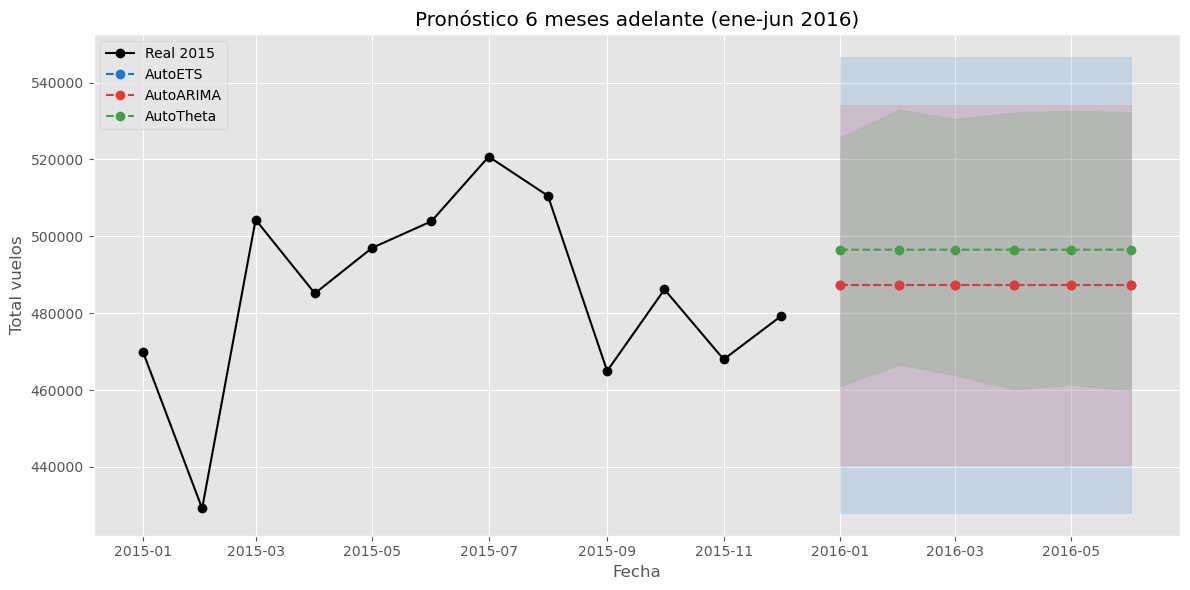

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_sf["ds"], df_sf["y"], "ko-", label="Real 2015", markersize=6)

forecast_future = forecast.tail(6)

for model_name, color in colors.items():
    ax.plot(forecast_future["ds"], forecast_future[model_name],
            "o--", color=color, label=model_name, markersize=6)
    lo = f"{model_name}-lo-90"
    hi = f"{model_name}-hi-90"
    if lo in forecast_future.columns:
        ax.fill_between(forecast_future["ds"],
                        forecast_future[lo], forecast_future[hi],
                        alpha=0.15, color=color)

ax.set_title("Pronóstico 6 meses adelante (ene-jun 2016)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Total vuelos")
ax.legend()
plt.tight_layout()
plt.show()

AutoETS: MAE = 9,531 vuelos/mes
AutoARIMA: MAE = 9,512 vuelos/mes
AutoTheta: MAE = 18,735 vuelos/mes


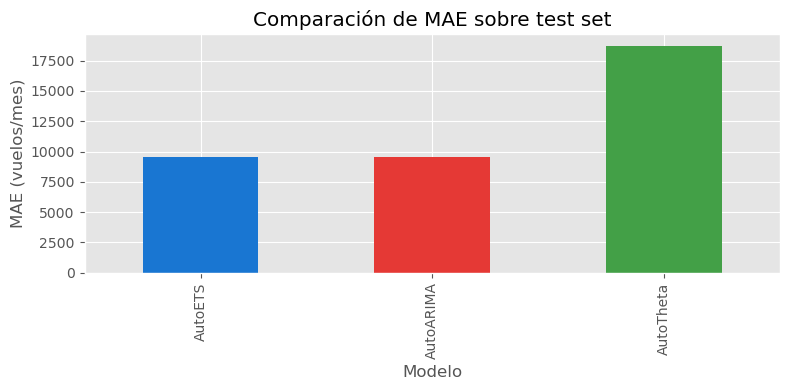

In [25]:
from sklearn.metrics import mean_absolute_error

mae_results = {}
for model_name in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    mae = mean_absolute_error(test["y"].values, forecast.head(3)[model_name].values)
    mae_results[model_name] = mae
    print(f"{model_name}: MAE = {mae:,.0f} vuelos/mes")

pd.DataFrame({"Modelo": mae_results.keys(), "MAE": mae_results.values()}).plot(
    kind="bar", x="Modelo", y="MAE", legend=False,
    color=["#1976d2", "#e53935", "#43a047"], figsize=(8, 4)
)
plt.title("Comparación de MAE sobre test set")
plt.ylabel("MAE (vuelos/mes)")
plt.tight_layout()
plt.show()

### Interpretación del Pronóstico

**Modelos seleccionados automáticamente:**
- AutoETS: (A,N,N) — aditivo, sin tendencia, sin estacionalidad
- AutoARIMA: ARIMA(0,1,0) — random walk
- AutoTheta: Theta no estacional

Los tres modelos seleccionaron especificaciones **no estacionales**, lo cual es correcto y esperado: con solo 9 puntos de entrenamiento no hay suficientes datos para estimar un ciclo estacional de 12 meses.

**MAE sobre test set (oct-dic 2015):**
- AutoETS: 9,531 vuelos/mes
- AutoARIMA: 9,512 vuelos/mes ← mejor desempeño
- AutoTheta: 18,735 vuelos/mes

AutoARIMA tiene el menor MAE, seguido muy de cerca por AutoETS. AutoTheta tiene el peor desempeño con casi el doble de error. Los intervalos de confianza al 90% son amplios en los tres modelos, lo que refleja la alta incertidumbre inherente a pronosticar con solo 9 observaciones de entrenamiento.